# Introduction

This notebook performs a  **M**eta-**A**nalytic **C**o-activation **M**odeling (MACM) to functionally subdivide VMPFC into distinct subregions. Unlike predefined anatomical atlases, CBP is a data-driven approach that assumes voxels with similar whole-brain co-activation profiles across thousands of studies likely share similar functional roles.

In [ ]:
from neurosynth import Dataset
from neurosynth.analysis.cluster import Clusterable
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances, davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA
from copy import deepcopy
import joblib
from pathlib import Path
import nibabel as nib
import numpy as np
import nilearn.plotting as nplt
import matplotlib.pyplot as plt
import warnings

plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'Arial'
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path('../data')
PLOTS_PATH = Path('../plots')
RESULTS_PATH = Path('../results')

DATASET_FILE = DATA_PATH / 'neurosynth_data/dataset.pkl'
ROI_FILE = DATA_PATH / 'masks/VMPFC_mask_v2.nii'
unROI_FILE = DATA_PATH / 'masks/unVMPFC_mask_v2.nii'
N_CLUSTER_LIST = list(range(2, 7))
MIN_STUDIES = 150 # min studies for activation
N_COMPONENTS = 100 # number of PCA components

RANDOM_STATE = 2018

In [3]:
# load mask image
# ROI mask and co-activation region (whole brain or region after removing ROI)
ROI_IMAGE = nib.load(str(ROI_FILE))
print(f'ROI mask includes {ROI_IMAGE.get_fdata().sum():.0f} voxels.')
unROI_IMAGE = nib.load(str(unROI_FILE))
print(f'unROI mask includes {unROI_IMAGE.get_fdata().sum():.0f} voxels.')

dataset = Dataset.load(DATASET_FILE)

ROI mask includes 3918 voxels.
unROI mask includes 224756 voxels.


# Data Masking
We first extract the activation data for both the target region (`ROI`: VMPFC) and the rest of the brain (`unROI`).

In [5]:
# extract masked dataset (ROI and unROI), which is activation data
ROI_dataset = Clusterable(dataset, mask=ROI_IMAGE)
ROI_activation_raw = ROI_dataset.data
print(f'ROI dataset: (n voxels, n studies) = {ROI_dataset.data.shape}.')

# masker, to map vector back to brain voxels
ROI_masker = deepcopy(dataset.masker)
ROI_masker.add({'roi': ROI_IMAGE})

# remaining voxels to compare
unROI_dataset = Clusterable(dataset, mask=unROI_IMAGE)
unROI_activation_raw = unROI_dataset.data
print(f'unROI dataset: (n voxels, n studies) = {unROI_dataset.data.shape}.')

# masker, to map vector back to brain voxels
unROI_masker = deepcopy(dataset.masker)
unROI_masker.add({'roi': unROI_IMAGE})



ROI dataset: (n voxels, n studies) = (3697, 14371).
unROI dataset: (n voxels, n studies) = (224756, 14371).


# Thresholding

 To ensure high signal-to-noise ratio and statistical reliability, we apply a strict spatial threshold: only voxels that are reported as active in a minimum number of studies (`MIN_STUDIES = 150`) are retained for downstream analysis.

In [6]:
# map of voxels changes based on the minimum number of studies
ROI_studies_per_voxel = ROI_activation_raw.sum(1)
ROI_image = ROI_masker.unmask(ROI_studies_per_voxel)
ROI_image = nib.nifti1.Nifti1Image(ROI_image, affine=ROI_IMAGE.affine, )

unROI_studies_per_voxel = unROI_activation_raw.sum(1)
unROI_image = unROI_masker.unmask(unROI_studies_per_voxel)
unROI_image = nib.nifti1.Nifti1Image(unROI_image, affine=unROI_IMAGE.affine, )

ROI_voxels_to_use = ROI_studies_per_voxel >= MIN_STUDIES
ROI_activation = ROI_activation_raw[ROI_voxels_to_use, :]
print(f'ROI dataset: (n voxels, n studies) = {ROI_activation.data.shape}.')

unROI_voxels_to_use = unROI_studies_per_voxel >= MIN_STUDIES
unROI_activation = unROI_activation_raw[unROI_voxels_to_use, :]
print(f'unROI dataset: (n voxels, n studies) = {unROI_activation.data.shape}.')

#  Dimensionality Reduction and Co-activation Profiling
The whole-brain co-activation data is massive and inherently noisy. To address this, we apply Principal Component Analysis (PCA) to the `unROI` dataset. By extracting the top components (`N_COMPONENTS = 100`), we effectively denoise the data and isolate the most prominent functional co-activation networks across the brain, while significantly reducing computational overhead.

For every valid voxel within the VMPFC, we compute its Pearson correlation distance (`1 - r`) against the extracted whole-brain Principal Components. This generates a comprehensive co-activation matrix, essentially yielding a functional "fingerprint" for each VMPFC voxel.

In [7]:
# decompose the data to remove noise and reduce data dimensions
pca = PCA(n_components=N_COMPONENTS, svd_solver='randomized', random_state=RANDOM_STATE)
unROI_activation_PCs = pca.fit_transform(unROI_activation.T).T
print(f'unROI dataset: (n PCs, n studies) = {unROI_activation_PCs.shape}.')

# Finding the Pearson distance (1 - r) between voxels of ROI and unROI PCs
coactivation = pairwise_distances(ROI_activation, unROI_activation_PCs, metric='correlation', n_jobs=64)
print(f"coactivation: (n ROI voxels, n unROI voxels) = {coactivation.shape})")

ROI dataset: (n voxels, n studies) = (1784, 14371).
unROI dataset: (n voxels, n studies) = (129213, 14371).
unROI dataset: (n PCs, n studies) = (100, 14371).
coactivation: (n ROI voxels, n unROI voxels) = (1784, 100))


# K-Means Clustering & Validation
Using the co-activation matrix, we apply the K-Means clustering algorithm to group the VMPFC voxels into functionally homogeneous clusters. We explore a range of possible solutions (from $K=2$ to $K=6$). To determine the optimal number of clusters quantitatively, we evaluate the internal validity of each solution using two standard clustering metrics:
* **Silhouette Score:** Measures how similar an object is to its own cluster compared to other clusters (higher is better).
* **Davies-Bouldin Score:** Measures the average similarity ratio of each cluster with its most similar cluster (lower is better).

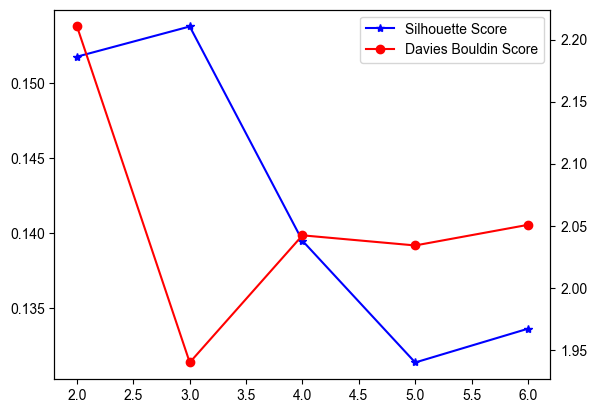

In [8]:
# Performing k-means (or other algorithms) clustering
label_dict = {
    n_clusters:
        KMeans(
            n_clusters=n_clusters,
            init='random',
            n_init=1000,
            random_state=RANDOM_STATE,
        ).fit_predict(coactivation) + 1
    for n_clusters in N_CLUSTER_LIST
}

# Validity measure of clusters
SS_scores = [silhouette_score(coactivation, label) for label in label_dict.values()]
DBI_scores = [davies_bouldin_score(coactivation, label) for label in label_dict.values()]
scores = dict(silhouette_scores=SS_scores, davies_bouldin_scores=DBI_scores)
joblib.dump(scores, RESULTS_PATH / 'scores.list', )

# fast plot for the internal validity scores
line1, = plt.plot(N_CLUSTER_LIST, SS_scores, 'b-*', )
plt.twinx()
line2, = plt.plot(N_CLUSTER_LIST, DBI_scores, 'ro-', )
plt.legend([line1, line2], ['Silhouette Score', 'Davies Bouldin Score'])

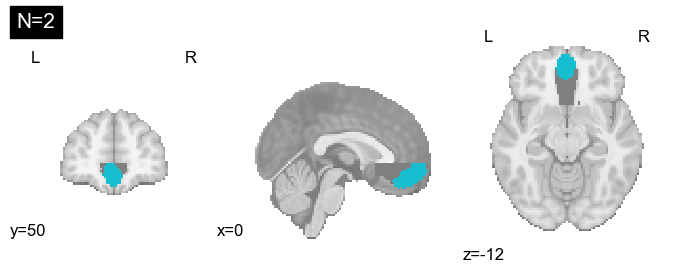

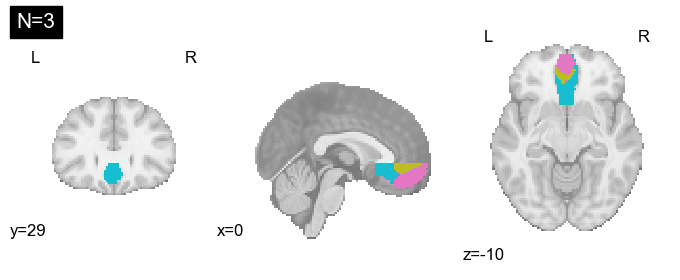

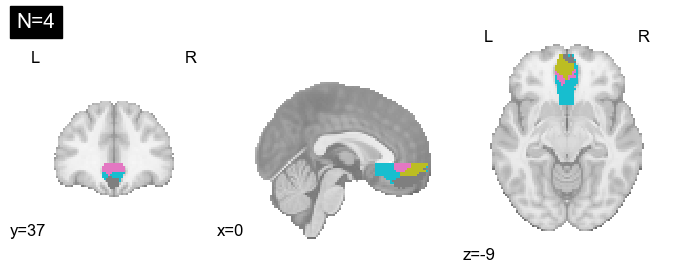

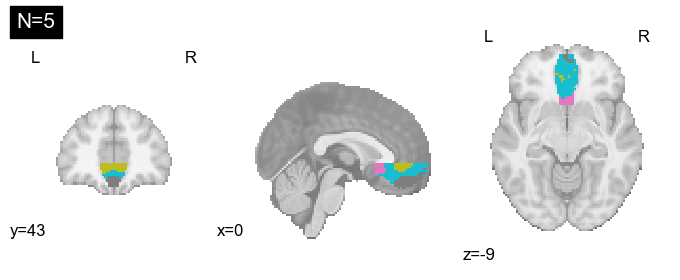

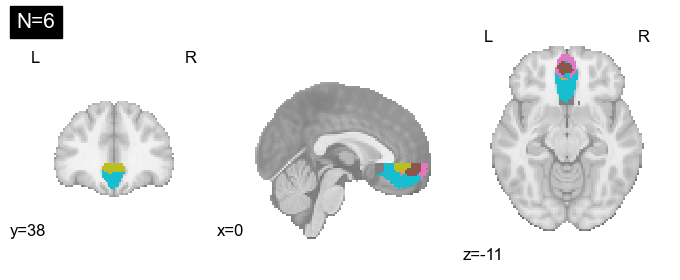

In [9]:
# plot and save image
for cluster_n in N_CLUSTER_LIST:
    label = np.zeros_like(ROI_studies_per_voxel, dtype=np.int8)
    label[ROI_voxels_to_use] = label_dict[cluster_n]
    label_img_data = ROI_masker.unmask(label)
    label_img = nib.nifti1.Nifti1Image(label_img_data, header=ROI_IMAGE.header, affine=ROI_IMAGE.affine, )
    nib.save(label_img, str(RESULTS_PATH / f'nii/K{cluster_n}.nii.gz'))
    # fast plot for solutions
    nplt.plot_stat_map(label_img, title=f'N={cluster_n}', cmap='tab10', draw_cross=False, colorbar=False, )